# Camada Silver - Qualidade da base de vacinação contra sarampo

Este notebook audita a **silver**: `data/vacinacao/processed/silver/vacinacao_sarampo_sipni.parquet`, uma linha por dose de vacina com componente de sarampo (SCR, SCRV, SR), de **jan/2025 a jun/2026**.

Arquitetura em camadas (medalhão):

| Camada | O que é | Onde / como é gerada |
|---|---|---|
| **Bronze** | CSVs mensais do SI-PNI/RNDS já filtrados para sarampo, sem tratamento | `processed/sipni_doses_sarampo_sipni_AAAA_mmm.csv` - `extract_recentes.py` |
| **Silver** | Limpa, tipada, enxuta (56 -> 28 colunas), sem duplicatas e sem diluentes | `processed/silver/` - `processar_vacinacao.py` |
| **Gold** | Tabelas agregadas pequenas, prontas para visualização e BI | `processed/gold/` - `gerar_gold.py` |

Ver [06-gold-panorama-vacinacao.ipynb](06-gold-panorama-vacinacao.ipynb) e [07-gold-criancas-municipios-atraso.ipynb](07-gold-criancas-municipios-atraso.ipynb) para as análises sobre a gold.

## 1. Setup

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

# Paleta categorica validada (blue, orange, aqua, yellow, magenta, green, violet, red)
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE = "#2a78d6"
TEXT_PRIMARY, TEXT_SECONDARY, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRID,
    "axes.labelcolor": TEXT_SECONDARY, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "text.color": TEXT_PRIMARY, "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
})
pd.options.display.float_format = "{:,.2f}".format

PROCESSED = Path("..") / "data" / "vacinacao" / "processed"
SILVER = PROCESSED / "silver" / "vacinacao_sarampo_sipni.parquet"
GOLD = PROCESSED / "gold"


def milhar(ax, eixo="y"):
    fmt = mtick.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", "."))
    (ax.yaxis if eixo == "y" else ax.xaxis).set_major_formatter(fmt)


def titulo(ax, texto):
    ax.set_title(texto, loc="left", fontweight="bold")

df = pd.read_parquet(SILVER)
print(f"{df.shape[0]:,} linhas x {df.shape[1]} colunas | {SILVER.stat().st_size/1e6:,.0f} MB em disco | {df.memory_usage(deep=True).sum()/1e9:.1f} GB em RAM")
df.head(3).T

11,757,577 linhas x 28 colunas | 542 MB em disco | 4.7 GB em RAM


,0,1,2
codigo_paciente_anonimizado,0062aaff6663abdbe1b004b07b87d866997e97de24dbf8...,008588c360d55f66f3a0c647d65c867499724c4672eb8b...,00ded1937dc180d30cfb6de432a4b4a9b4e7828ee97d35...
sexo_paciente,Masculino,Feminino,Masculino
raca_cor_paciente,PARDA,BRANCA,SEM INFORMACAO
codigo_municipio_paciente,330455,330455,330455
uf_paciente,RJ,RJ,RJ
nacionalidade_paciente,B,B,B
etnia_indigena_paciente,<NA>,<NA>,<NA>
codigo_cnes_estabelecimento,7892829,2288370,2269627
codigo_municipio_estabelecimento,330455,330455,330455
uf_estabelecimento,RJ,RJ,RJ


## 2. Funil de processamento (bronze -> silver)
Quantas linhas cada regra da silver removeu, por mês.

In [2]:
resumo = pd.DataFrame(json.loads((PROCESSED / "_auditoria" / "processamento_resumo.json").read_text(encoding="utf-8"))).T
resumo.index.name = "ano_mes"
display(resumo)
print("Total bronze:", f"{resumo.linhas_csv.sum():,}", "| diluentes removidos:", f"{resumo.diluentes_removidos.sum():,}",
      "| duplicadas removidas:", f"{resumo.duplicadas_removidas.sum():,}", "| silver:", f"{resumo.linhas_finais.sum():,}")

,linhas_csv,diluentes_removidos,duplicadas_removidas,linhas_finais,vacinacao_fora_do_mes
ano_mes,,,,,
2025-01,790000,22,0,789978,0
2025-02,626088,9,0,626079,0
2025-03,608801,23,0,608778,0
2025-04,619710,8,0,619702,0
2025-05,694887,12,0,694875,0
2025-06,628744,22,0,628722,0
2025-07,795324,30,0,795294,0
2025-08,795501,16,0,795485,0
2025-09,825400,40,0,825360,0


Total bronze: 11,758,072 | diluentes removidos: 495 | duplicadas removidas: 0 | silver: 11,757,577


## 3. Completude
Percentual de valores ausentes por coluna. Colunas quase vazias (etnia, condição maternal etc.) só fazem sentido em subpopulações.

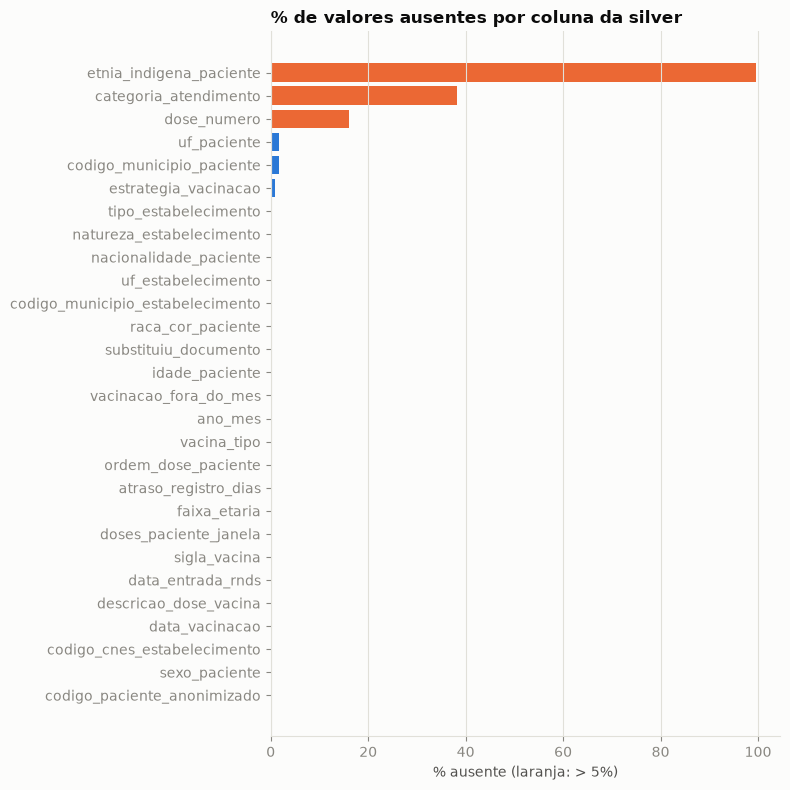

raca_cor_paciente                   0.00
codigo_municipio_estabelecimento    0.00
uf_estabelecimento                  0.00
nacionalidade_paciente              0.01
natureza_estabelecimento            0.09
tipo_estabelecimento                0.09
estrategia_vacinacao                0.83
codigo_municipio_paciente           1.68
uf_paciente                         1.69
dose_numero                        16.09
categoria_atendimento              38.29
etnia_indigena_paciente            99.53
dtype: float64

In [3]:
nulos = (df.isna().mean() * 100).sort_values()
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(nulos.index, nulos.values, color=[CATEGORICAL[1] if v > 5 else BLUE for v in nulos.values])
titulo(ax, "% de valores ausentes por coluna da silver")
ax.set_xlabel("% ausente (laranja: > 5%)")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()
nulos[nulos > 0].round(2)

## 4. Colunas categóricas
Cardinalidade e categorias dominantes: base para decidir o que vira filtro/cor nas visualizações.

In [4]:
cats = ["sexo_paciente", "raca_cor_paciente", "nacionalidade_paciente", "vacina_tipo", "sigla_vacina",
        "descricao_dose_vacina", "estrategia_vacinacao", "categoria_atendimento", "natureza_estabelecimento"]
resumo_cat = pd.DataFrame({
    "unicos": [df[c].nunique() for c in cats],
    "mais_frequente": [df[c].value_counts().index[0] for c in cats],
    "% mais_frequente": [100 * df[c].value_counts(normalize=True).iloc[0] for c in cats],
}, index=cats)
resumo_cat

,unicos,mais_frequente,% mais_frequente
sexo_paciente,3,Feminino,50.84
raca_cor_paciente,6,PARDA,42.46
nacionalidade_paciente,3,B,98.03
vacina_tipo,4,Tríplice viral (SCR),74.67
sigla_vacina,5,SCR,74.67
descricao_dose_vacina,34,1ª Dose,40.98
estrategia_vacinacao,14,Rotina,94.05
categoria_atendimento,23,Faixa Etária,91.65
natureza_estabelecimento,4,ADMINISTRACAO PUBLICA,97.71


## 5. Idade
A idade vem em anos completos. Vacinação em massa de sarampo concentra-se em crianças pequenas; valores muito altos são candidatos a erro de digitação.

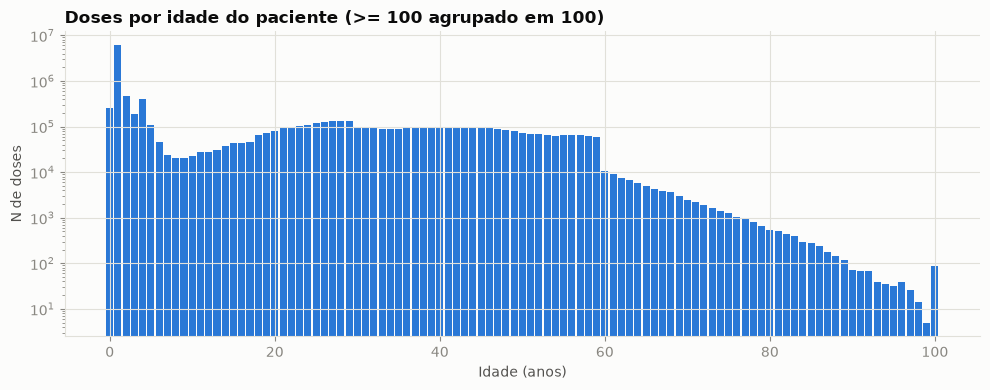

Idade > 100 anos: 86 | idade > 110: 54 | idade ausente: 0


In [5]:
idade = df["idade_paciente"].dropna().astype(int)
fig, ax = plt.subplots(figsize=(10, 4))
cont = idade.clip(upper=100).value_counts().sort_index()
ax.bar(cont.index, cont.values, color=BLUE, width=0.85)
titulo(ax, "Doses por idade do paciente (>= 100 agrupado em 100)")
ax.set_xlabel("Idade (anos)"); ax.set_ylabel("N de doses"); milhar(ax)
ax.set_yscale("log")
plt.tight_layout(); plt.show()
print("Idade > 100 anos:", f"{(idade > 100).sum():,}", "| idade > 110:", f"{(idade > 110).sum():,}", "| idade ausente:", df["idade_paciente"].isna().sum())

## 6. Pacientes com muitas doses
`codigo_paciente_anonimizado` permite seguir a mesma pessoa. Poucas doses por pessoa são esperadas (esquema de 2 doses). Valores extremos indicam **colisão de identificador** (mesmo hash para pessoas diferentes, p.ex. CPF/CNS inválido) e devem ser filtrados em análises por paciente.

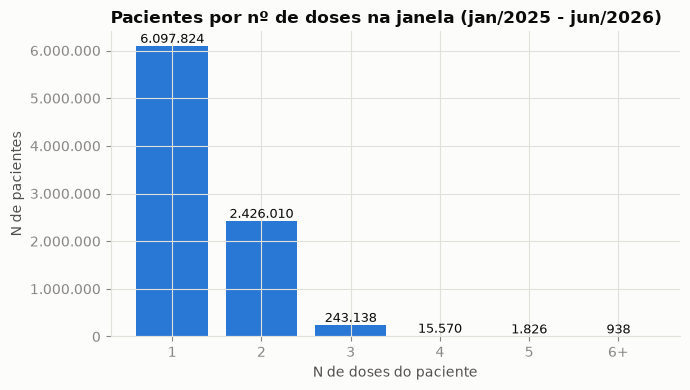

Pacientes únicos: 8,785,306


Pacientes com > 10 doses (provável colisão de ID): 28 -> doses: 859


In [6]:
por_paciente = df.groupby("codigo_paciente_anonimizado").size()
dist = por_paciente.clip(upper=6).value_counts().sort_index()
dist.index = [str(i) if i < 6 else "6+" for i in dist.index]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(dist.index, dist.values, color=BLUE)
titulo(ax, "Pacientes por nº de doses na janela (jan/2025 - jun/2026)")
ax.set_xlabel("N de doses do paciente"); ax.set_ylabel("N de pacientes"); milhar(ax)
for i, v in enumerate(dist.values):
    ax.text(i, v, f"{v:,.0f}".replace(",", "."), ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()
print("Pacientes únicos:", f"{por_paciente.size:,}")
print("Pacientes com > 10 doses (provável colisão de ID):", f"{(por_paciente > 10).sum():,}", "-> doses:", f"{por_paciente[por_paciente > 10].sum():,}")

## 7. Descrição da dose x ordem real da dose
16% das linhas trazem a dose só como "Dose", sem número. A silver calcula `ordem_dose_paciente` (1ª, 2ª... dose do paciente **dentro da janela**) para resolver isso. Limite: doses aplicadas antes de jan/2025 não aparecem, então a ordem é um **mínimo**.

In [7]:
ct = pd.crosstab(df["descricao_dose_vacina"], df["ordem_dose_paciente"].clip(upper=4))
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index].head(8)
ct.columns = ["1º na janela", "2º na janela", "3º na janela", "4º+ na janela"]
ct

,1º na janela,2º na janela,3º na janela,4º+ na janela
descricao_dose_vacina,,,,
1ª Dose,4478139,316420,20170,4110
Única,1175844,1392055,149773,10555
2ª Dose,1068761,926885,87532,7457
Dose,1834082,40220,3019,985
Dose Zero,216402,7388,400,132
1º Reforço,3809,2369,177,16
Reforço,3535,820,103,8
3ª Dose,965,272,154,20


## 8. Registro no RNDS: atraso e datas inconsistentes

In [8]:
at = df["atraso_registro_dias"].dropna().astype(int)
print("Datas de vacinação fora do mês do arquivo:", int(df["vacinacao_fora_do_mes"].sum()))
print("Registro antes da vacinação (atraso < 0):", int((at < 0).sum()))
print(at.describe(percentiles=[.5, .75, .9, .99]).round(1).to_string())

Datas de vacinação fora do mês do arquivo: 0
Registro antes da vacinação (atraso < 0): 0


count   11,757,577.00
mean            18.20
std             48.80
min              0.00
50%              2.00
75%             13.00
90%             44.00
99%            266.00
max            587.00


## Conclusões da auditoria
- A silver está **sem duplicatas** de documento e sem diluentes; o funil (seção 2) documenta tudo o que saiu.
- A **data de vacinação sempre cai no mês do arquivo**, então `ano_mes` pode ser usado com segurança como período.
- Análises **por paciente** devem excluir pacientes com número absurdo de doses (colisão de ID).
- Para **cobertura vacinal** ainda falta o denominador populacional (IBGE/SINASC); as tabelas gold contam doses e pacientes vacinados, não cobertura.